<h2><center>Assignment 4</center></h2>
<h3><center>Programming for Data Science 2026</center></h3>
<b><center>Deadline: 14:00, March 26, 2026</center></b>

- The exercise will be marked as **passed** if you get **at least 10/16** points.

- Exercises must be handed in via **ILIAS** (Homework assignments). Submit your work as a **compressed (.zip)** file containing **one** `.py` **or** `.ipynb` file with **all exercises**.

- The name of **both** the `.zip` file and the `.py`/`.ipynb` file must be the *SurnameName* of the **two group members**, separated by an underscore.  
  Example: Tim Tabellen and Lara Lambda → `TabellenTim_LambdaLara.zip`  
  (The `.py`/`.ipynb` file must have the same name.)

- Use **comments** to explain your code and demonstrate that you understand the solutions and can discuss them.

- You are not expected to collaborate outside your group. Submitting other groups’ code as your own will result in **0 points**.

- For general questions about the lecture content, assignments, or the exam, please use the **ILIAS forum**.

- For individual questions about lecture content and the exam, contact: *roland.widmer@students.unibe.ch*  

- For individual questions about the exercises or grading, contact: *julien.brunner@students.unibe.ch* or *aline.steiner@students.unibe.ch*

#### Exercise 1: Sum of squares *(1 point)*

The code below squares and sums the numbers in the array `arr`, and holds the result in the variable `sum_of_squares`, which should be 1135.

However, that is not the case. Explain what is wrong and how we may correct it.

In [ ]:
import numpy as np

arr = np.array([13, 14, 15, 16, 17], dtype=np.int8)
sum_of_squares = np.sum(arr ** 2)
sum_of_squares

**Your answer:** TODO

#### Exercise 2: Broadcasting *(2 points)*

Reshape `scaling_factors` so it is possible to multiply `data` and `scaling_factors`, and explain why you had to reshape `data` to be able to multiply the two arrays.

`data` contains 4 trials with 2 measurement, `scaling_factors` a scaling factor for all 4 trials.

In [11]:
import numpy as np

data = np.array([[1, 2], [4, 5], [2, 4], [1, 4]])
scaling_factors = np.array([2, 1, 2, 1])

# using .reshape() to bring scaling_factors into appropriate format
scaling_factors = scaling_factors.reshape((4,1))

# multiply scaling factors and data
print(f'The resulting multiplication results in the following matrix: \n{scaling_factors * data}')





The resulting multiplication results in the following matrix: 
[[2 4]
 [4 5]
 [4 8]
 [1 4]]


**Your answer**: *scaling_factors* was a "matrix" of form 1x4, whereas *data* was of form 4x2. By reshaping *scaling_factors* to a 4x1 matrix it becomes compatible with the *data* matrix. *scaling_factors* will be simply reused to compensate for its shorter column length. That means conceptually the calculation behaves as if the amount of columns were doubled to match the shape of the bigger *data* matrix.

#### Exercise 3: Base converter *(2 points)*

Write a function `int_to_bin` that takes a positive integer as input and returns the binary equivalent of that integer as a string.

You can **not** use built-in methods such as `bin()` in your solution.

Hint: The % operator could be useful to solve this exercise.

In [ ]:
# TODO

#### Exercise 4: Sales *(2 points)*

The array represents `sales` per day (in CHF). The rows represent the item, the columns the day.

Example: On Monday, item 1 has had a revenue of $120.-$

In [13]:
sales = np.array([[120, 160, 100, 130, 170, 25, 0], [90, 115, 95, 105, 125, 3, 0]], dtype=np.float64)

Suppose a discount was applied to days, where sales exceeded $100.-$. Write a NumPy expression to get a boolean array indicating which sales values qualify for the discount.

In [ ]:
# creating new variable discount, which gives boolean array (>100), excluding 100 itself.
discount = sales > 100

# print discount
print(discount)


[[ True  True False  True  True False False]
 [False  True False  True  True False False]]


The discount was set to be 15%. Adapt the sales according to this discount.

In [ ]:
# creating a new array where all values above 100 are value*0.85 and the rest stays the same
sales_w_discount = np.where(discount, sales * 0.85, sales)

# print output array
print(sales_w_discount)

[[102.   136.   100.   110.5  144.5   25.     0.  ]
 [ 90.    97.75  95.    89.25 106.25   3.     0.  ]]


#### Exercise 5: Audio signal *(3 points)*

We load two sounds and define a helper function to save sounds to the `output` folder. Note that both sounds are mono and have the same sampling frequency.

In [4]:
import os

from scipy.io.wavfile import read, write

fs_bird, sound_bird = read("../data/audio/bird.wav")
fs_leaves, sound_leaves = read("../data/audio/leaves.wav")

def write_sound(sound, name="sound.wav", fs=44100):
    os.makedirs(os.path.join("..", "output"), exist_ok=True)
    write(os.path.join("..", "output", name), rate=fs, data=sound)

The two sounds do not have the same length (number of samples). Print the lengths of both sounds and create a modified version of the leaves sound that has the same length as the bird sound by cropping it (making it shorter).

In [ ]:
# TODO

Create a silence period (0 amplitude) of the same duration of the two sounds, using NumPy.

In [ ]:
# TODO

Finally, concatenate the diffent sounds into a single one. The order should be: silence, birds, silence, leaves (cropped), silence. Print the shape of the concatenated sound and save the sound using `write_sound`. Listen to the sound, did it work?

In [ ]:
# TODO

#### Exercise 6: Owl revisited *(1 point)*

We start with the grayscale owl from the last assignment.

(1536, 1024, 3)


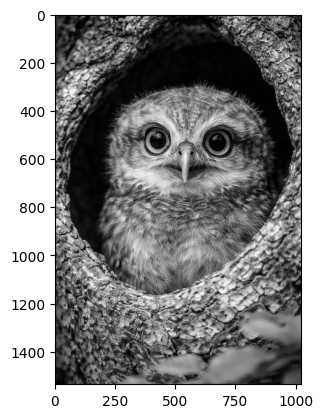

In [20]:
import matplotlib.pyplot as plt
import numpy as np

def load_gray_scale_image(path):
    image_data = plt.imread(path)
    image_data = np.array(image_data)
    image_data = (0.2989 * image_data[:, :, 0] + 0.5870 * image_data[:, :, 1] + 0.1140 * image_data[:, :, 2]).astype(np.uint8)
    image_data = np.stack([image_data] * 3, axis=-1)
    return image_data

def plot_image(image_data):
    plt.imshow(image_data)
    plt.show()

image_data = load_gray_scale_image("../data/images/owl.jpg")

print(image_data.shape)

plot_image(image_data)

Replace all dark pixels (value below 30) with a red color and plot it with `plot_image`.

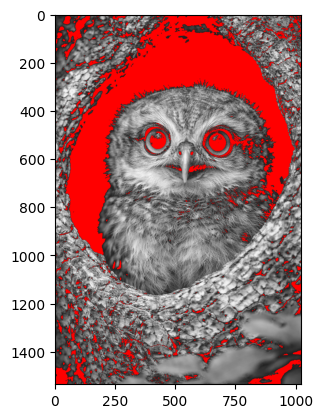

In [24]:
# creating mask, accordingly
mask = image_data[:,:,0] < 30

# all pixels matching the mask are set to red ([255, 0, 0])
image_data[mask] = [255,0,0]

# plot final image
plot_image(image_data)

#### Exercise 7: Aare revisited *(2 points)*

In this exercise, we work with daily water temperature data from the Aare river in Bern again. 

Source: [Hydrology Division, Federal Office for the Environment FOEN (2026)](https://www.hydrodaten.admin.ch/en/seen-und-fluesse/messstationen-temperatur).

First, we define some helper functions:

- `get_temperature_data`: returns the daily temperature data for 2004-2025
- `plot_temperature`: plots the the temperature for a given numpy array

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def get_temperature_data():
    temperature_df = pd.read_csv(f"../data/csv/aare_temperature.csv", parse_dates=["timestamp"])
    
    return temperature_df["value"].to_numpy()



def plot_temperature(temperature_data, time_unit="days"):
    plt.plot(temperature_data)
    plt.xlabel(f"Time ({time_unit})")
    plt.ylabel("Temperature (°C)")
    plt.title(f"Temperature over time")
    plt.show()


temperature = get_temperature_data()
plot_temperature(temperature)


Count how many days were bathable (i.e., water temperature was above 18 °C). Also give the percentage of bathable days compared to all days.

In [ ]:
# TODO

Set the temperature of all 'non-bathable' days to `np.nan`. Calculate the mean temperature of remaining days.

In [ ]:
# TODO

#### Exercise 8: Vacation recommendations *(3 points)*

The code below defines five vacation destinations (`locations`) and four attributes for each (`attributes`). Each row describes one destination, and the columns represent scores on the factors scenery, activities, food, and nightlife.

Write a function `vacation_advisor` that asks the user whether they find each of the attributes important or not, and suggests the best vacation spot based on these preferences. If the user inputs `n` for all of the questions, print a message and ask again. Use techniques from the lecture to solve the exercise.

Hints:
- Translate the preferences (i.e., y/n) into a binary vector.
- Select attributes using the preferences to calculate a score per country.
- If multiple countries have the same score, return the first one.

Example interaction:
```raw
Is scenery important to you [y/n]?    > y
Is activities important to you [y/n]? > y
Is food important to you [y/n]?       > n
Is nightlife important to you [y/n]?  > n
Based on your preferences, the best destination is Australia
```

In [25]:
locations = np.array([ "Hawaii", "Thailand", "Italy", "Australia", "Japan"])

# List of attributes for each destination. Each column is an attribute. Each row a destination.
attributes = np.array([
    [8, 8, 7, 6],
    [7, 9, 8, 7],
    [8, 6, 9, 7],
    [9, 8, 8, 6],
    [7, 9, 7, 8]
])

# Declare attribute names and initialize boolean array with preferences
attribute_names = ["scenery", "activities", "food", "nightlife"]

In [ ]:
def vacation_advisor(attribute_names, attributes, locations):
    
    # creating a vector of attribute importance
    importance = np.zeros(len(attribute_names))
    
    # while loop to catch for no-answers only
    while not importance.any():
        
        # filling the vector of attribute inportance according to the users answer
        for i in range(len(attribute_names)):
            answer = input(f'Is {attribute_names[i]} important to you [y/n]?')
            answer = np.where(answer == 'y', 1, 0)
            importance[i] = answer

        # checking if all answers were "no"
        if not importance.any():
            really = input('Do you really want to go to vacation? [y,n]')
            if really == 'n':
                print("you don't wanna go to vacation! sad!")
                break
            
    # multiplying importance with attributes to receive a scoring matrix
    scores = importance * attributes

    # getting row index of destination with highest scores
    decision = np.sum(scores, axis=1)
    index = np.argmax(decision) # (note argmx returns only the first value if there are multiples with the same score)

    # printing the final result
    return(f'The best matching destination for you is {locations[index]}')

vacation_advisor(attribute_names, attributes, locations)




'The best matching destination for you is Thailand'